In [1]:
# Primary GeONet code. Run to train network and/or see results
# Authors: Andrew Gracyk, Xiaohui Chen

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.autograd import Variable
import numpy as np

In [2]:
#### Run this code even if using pre-trained model

print("Creating neural networks.")
%run GeONet_Models

Creating neural networks.


In [220]:
#### Define physics-informed loss
#### No need to run this code if using pre-trained model
%run Physics_informed_loss

In [222]:
#### Create Gaussian mixture data
#### No need to run this code if using pre-trained model
print("Creating Gaussian mixture data.")
%run Gaussian_mixture_data_creation

Creating Gaussian mixture data.


In [226]:
###### Train the neural networks
#### No need to run this code if using pre-trained model
print("Training the neural networks.")
%run Training_algorithm

Training the neural networks.


In [ ]:
iterations = 4000
num_batches = 150
batch_size = 30*30*10
num_rows = 50  # Number of most recent losses to calculate loss coefficients
coefficients = np.zeros(shape=(4)) # Initialize vector to store loss-scaling coefficients
loss_matrix = np.random.rand(num_rows,4) # Initialize matrix of loss coefficients

training_algorithm(iterations, num_batches, batch_size, N, num_training_data, \
                    u0, u1, u0_vector, u1_vector, X_vector, Y_vector, pt_all_zeros, \
                    Cty, HJ, \
                    Cty_branch0, Cty_branch1, Cty_trunk, \
                    HJ_branch0, HJ_branch1, HJ_trunk, \
                    num_rows, coefficients, loss_matrix)

In [38]:
#### Load in saved neural network parameters here

#### Remove or change map_location=device from torch.load argument if parameters are from a different location

#### Model was trained with variance in 0.35 to 0.9, means in 1.2 to 3.8, covariance in -0.2 to 0.2, and pi_i=0.2 for i=1,...,5

torch.load

File = "Cty_branch0.pth"
Cty_branch0.load_state_dict(torch.load(File, map_location=device)) 

File = "Cty_branch1.pth"
Cty_branch1.load_state_dict(torch.load(File, map_location=device)) 

File = "Cty_trunk.pth"
Cty_trunk.load_state_dict(torch.load(File, map_location=device)) 

File = "HJ_branch0.pth"
HJ_branch0.load_state_dict(torch.load(File, map_location=device)) 

File = "HJ_branch1.pth"
HJ_branch1.load_state_dict(torch.load(File, map_location=device)) 

File = "HJ_trunk.pth"
HJ_trunk.load_state_dict(torch.load(File, map_location=device)) 

<All keys matched successfully>

GeONet results:


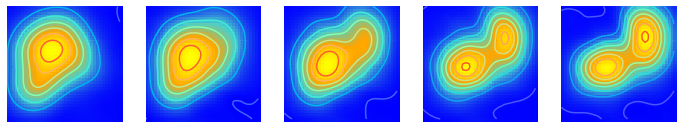

Reference results:


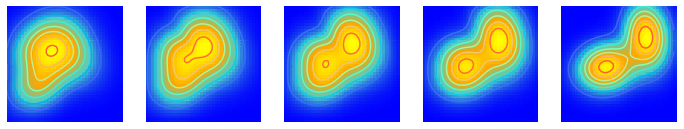

In [51]:
%run Test_results

test_results(Cty_branch0, Cty_branch1, Cty_trunk, HJ_branch0, HJ_branch1, HJ_trunk)